In [2]:
%matplotlib inline
%load_ext autoreload 
%autoreload 2

import os
import sys
import copy 
import warnings
from time import time

from astropy.table import Table, Column, vstack

import numpy as np 

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches

from astroML.stats import binned_statistic_2d

plt.rc('text', usetex=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the galaxy and star catalog

In [3]:
s18a_dir = '/Users/song/data/massive/s18a'

s18a_galaxy_dir = os.path.join(s18a_dir, 'galaxy')
s18a_star_dir = os.path.join(s18a_dir, 'star')

# Using the GAMA09 and VVDS region as examples
## Galaxies
g09_gal = Table.read(os.path.join(s18a_galaxy_dir, 's18a_wide_icmod_22_gal_g09.fits'))
vvd_gal = Table.read(os.path.join(s18a_galaxy_dir, 's18a_wide_icmod_22_gal_vvd.fits'))

print(len(g09_gal), len(vvd_gal))

## Stars
g09_star = Table.read(os.path.join(s18a_star_dir, 's18a_wide_ipsf_21_26_g09.fits'))
vvd_star = Table.read(os.path.join(s18a_star_dir, 's18a_wide_ipsf_21_26_vvd.fits'))

print(len(g09_star), len(vvd_star))

(1455576, 1669720)
(1976954, 2259259)


In [4]:
def mag_select(table, mag_col, low, upp):
    """Select subsample using magnitude cuts"""
    return table[(table[mag_col] > low) & (table[mag_col] <= upp)]

In [5]:
gal_test = mag_select(g09_gal, 'i_cmodel_mag', 15.0, 17.5)

star_test = mag_select(g09_star, 'i_psfflux_mag', 20.0, 23.0)

print(len(gal_test), len(star_test))

(8431, 340943)


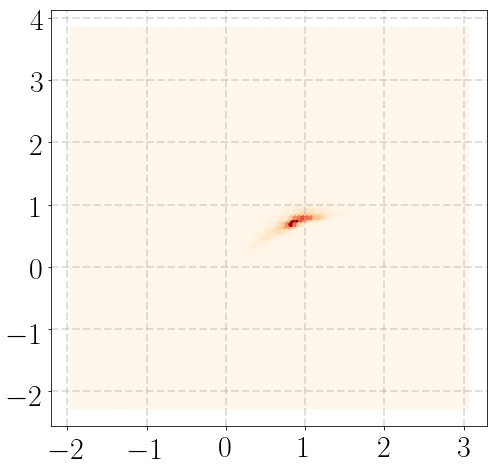

In [20]:
fig = plt.figure(figsize=(7, 7))
fig.subplots_adjust(left=0.13, right=0.995,
                    bottom=0.17, top=0.995,
                    wspace=0.00, hspace=0.00)
ax1 = fig.add_subplot(111)
ax1.grid(linestyle='--', linewidth=2, alpha=0.4, zorder=0)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(30)
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(30)

gr_color = ((gal_test['g_cmodel_mag'] - gal_test['a_g']) - 
            (gal_test['r_cmodel_mag'] - gal_test['a_r']))
rz_color = ((gal_test['r_cmodel_mag'] - gal_test['a_r']) - 
            (gal_test['z_cmodel_mag'] - gal_test['a_z']))

ax1.hexbin(gr_color, rz_color, cmap='OrRd')

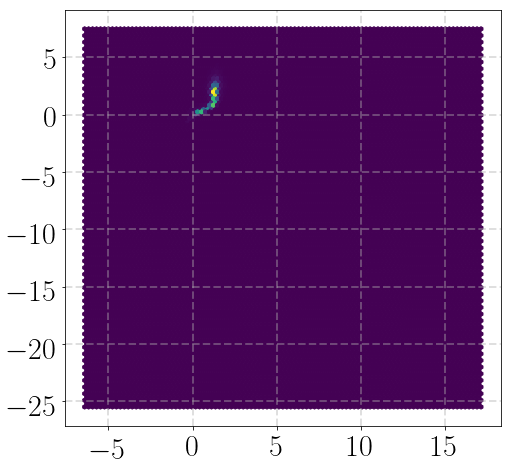

In [13]:
fig = plt.figure(figsize=(7, 7))
fig.subplots_adjust(left=0.13, right=0.995,
                    bottom=0.17, top=0.995,
                    wspace=0.00, hspace=0.00)
ax1 = fig.add_subplot(111)
ax1.grid(linestyle='--', linewidth=2, alpha=0.4, zorder=0)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(30)
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(30)

gr_color = ((star_test['g_psfflux_mag'] - star_test['a_g']) - 
            (star_test['r_psfflux_mag'] - star_test['a_r']))
rz_color = ((star_test['r_psfflux_mag'] - star_test['a_r']) - 
            (star_test['z_psfflux_mag'] - star_test['a_z']))
    
ax1.hexbin(gr_color, rz_color)

In [6]:
gal_mask = ((g09_gal['i_cmodel_mag'] >= 14.0) & 
            (g09_gal['i_cmodel_mag'] <= 16.5) &
            np.isfinite(g09_gal['g_cmodel_mag']) &
            np.isfinite(g09_gal['r_cmodel_mag']) & 
            np.isfinite(g09_gal['z_cmodel_mag']) & 
            (g09_gal['g_cmodel_mag'] - g09_gal['r_cmodel_mag'] >= 0.4) &
            (g09_gal['g_cmodel_mag'] - g09_gal['r_cmodel_mag'] <= 1.4) &
            (g09_gal['r_cmodel_mag'] - g09_gal['z_cmodel_mag'] >= 0.6) &
            (g09_gal['r_cmodel_mag'] - g09_gal['z_cmodel_mag'] <= 1.2)
           )

print(gal_mask.sum())

1618


/usr/local/lib/python2.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in subtract
  
/usr/local/lib/python2.7/site-packages/astropy/table/column.py:954: RuntimeWarning: invalid value encountered in greater_equal
  return getattr(self.data, op)(other)
/usr/local/lib/python2.7/site-packages/astropy/table/column.py:954: RuntimeWarning: invalid value encountered in less_equal
  return getattr(self.data, op)(other)
/usr/local/lib/python2.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in subtract
  if __name__ == '__main__':


In [7]:
star_mask = ((g09_star['i_psfflux_mag'] >= 20.0) & 
             (g09_star['i_psfflux_mag'] <= 24.5) &
             np.isfinite(g09_star['g_psfflux_mag']) &
             np.isfinite(g09_star['r_psfflux_mag']) & 
             np.isfinite(g09_star['z_psfflux_mag']) & 
             (g09_star['g_cmodel_mag'] - g09_star['z_cmodel_mag'] >= 0.8) &
             (g09_star['g_cmodel_mag'] - g09_star['z_cmodel_mag'] <= 1.4) &
             (g09_star['g_cmodel_mag'] - g09_star['i_cmodel_mag'] >= 0.6) &
             (g09_star['g_cmodel_mag'] - g09_star['i_cmodel_mag'] <= 1.2)
            )

print(star_mask.sum())

49128


/usr/local/lib/python2.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in subtract
  


In [8]:
gal_test = g09_gal[gal_mask]
star_test = g09_star[star_mask]

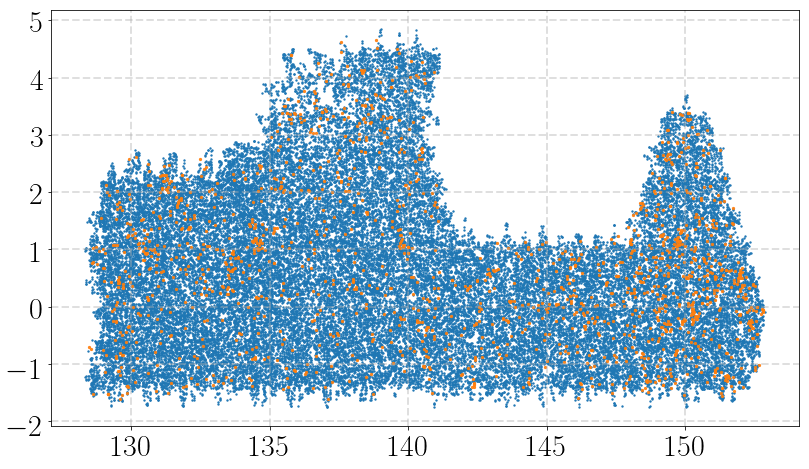

In [9]:
fig = plt.figure(figsize=(12, 7))
fig.subplots_adjust(left=0.13, right=0.995,
                    bottom=0.17, top=0.995,
                    wspace=0.00, hspace=0.00)
ax1 = fig.add_subplot(111)
ax1.grid(linestyle='--', linewidth=2, alpha=0.4, zorder=0)

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(30)
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(30)
    
ax1.scatter(star_test['ra'], star_test['dec'], s=2, alpha=0.9)
ax1.scatter(gal_test['ra'], gal_test['dec'], s=5, alpha=0.9)

In [10]:
import treecorr